Running DISCRETE Saaty-scale simulations...

n=4 -> reversal frequency = 0.2954
n=5 -> reversal frequency = 0.4922
n=6 -> reversal frequency = 0.6376
n=7 -> reversal frequency = 0.8004
n=8 -> reversal frequency = 0.8946
n=9 -> reversal frequency = 0.9506

Results saved to: discrete\discrete_iop_results.xlsx


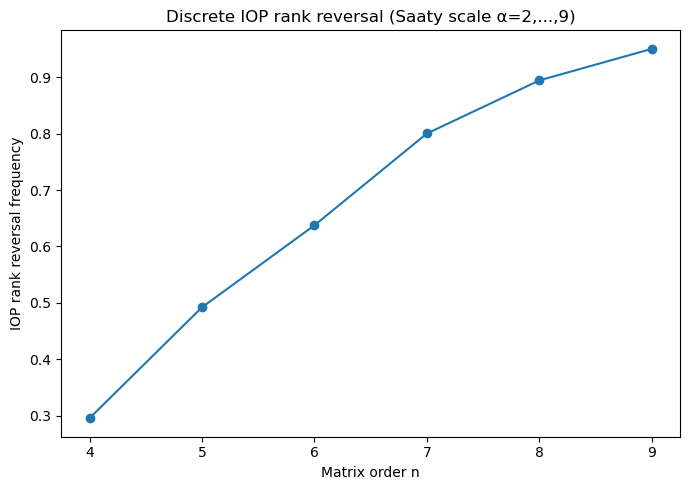

Figure saved to: discrete\discrete_iop_rank_reversal.jpeg


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig

# =========================================================
# 1. Eigenvector priority method
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = eigenvectors[:, idx].real
    w = np.abs(w)
    return w / np.sum(w)


# =========================================================
# 2. Ranking induced by weights
# =========================================================

def ranking(weights):
    return np.argsort(-weights)


# =========================================================
# 3. Generate ORDINAL PCM
# =========================================================

def random_ordinal_pcm(n):
    """
    Generate random ordinal reciprocal matrix with entries:
    {1, P, 1/P}
    """

    A = np.ones((n, n), dtype=object)

    for i in range(n):
        for j in range(i + 1, n):

            choice = np.random.choice(["tie", "pref", "notpref"])

            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1

            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"

            else:  # notpref
                A[i, j] = "1/P"
                A[j, i] = "P"

    return A


# =========================================================
# 4. Substitute alpha into ordinal PCM
# =========================================================

def substitute_alpha(A_ordinal, alpha):

    n = A_ordinal.shape[0]
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(n):

            if A_ordinal[i, j] == "P":
                A[i, j] = alpha
            elif A_ordinal[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0

    return A


# =========================================================
# 5. Discrete IOP rank reversal experiment
# =========================================================

def discrete_iop_reversal(n, trials=5000):

    alpha_values = list(range(2, 10))
    reversals = 0

    for _ in range(trials):

        A_ord = random_ordinal_pcm(n)

        rankings = []

        for alpha in alpha_values:
            A = substitute_alpha(A_ord, alpha)
            w = eigenvector_priority(A)
            rankings.append(ranking(w))

        baseline = rankings[0]  # alpha = 2

        if any(not np.array_equal(baseline, r) for r in rankings[1:]):
            reversals += 1

    return reversals / trials


# =========================================================
# 6. Create output folder
# =========================================================

output_dir = "discrete"
os.makedirs(output_dir, exist_ok=True)


# =========================================================
# 7. Run simulations
# =========================================================

np.random.seed(42)

n_values = [4, 5, 6, 7, 8,9]
trials = 5000

results = []

print("Running DISCRETE Saaty-scale simulations...\n")

for n in n_values:
    freq = discrete_iop_reversal(n=n, trials=trials)
    results.append((n, freq))
    print(f"n={n} -> reversal frequency = {freq:.4f}")


# =========================================================
# 8. Save results to Excel
# =========================================================

df = pd.DataFrame(results, columns=["Matrix size (n)", "IOP reversal frequency"])

excel_path = os.path.join(output_dir, "discrete_iop_results.xlsx")
df.to_excel(excel_path, index=False)

print(f"\nResults saved to: {excel_path}")


# =========================================================
# 9. Plot results
# =========================================================

plt.figure(figsize=(7, 5))
plt.plot(df["Matrix size (n)"], df["IOP reversal frequency"], marker="o")

plt.xlabel("Matrix order n")
plt.ylabel("IOP rank reversal frequency")
plt.title("Discrete IOP rank reversal (Saaty scale α=2,...,9)")
plt.xticks(n_values)

plt.tight_layout()

figure_path = os.path.join(output_dir, "discrete_iop_rank_reversal.jpeg")
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

Running DISCRETE CR analysis for n=7...

Raw results saved to: discrete\discrete_cr_analysis.xlsx

Number of matrices per CR group:

CR_group
CR < 0.10    6375
CR ≥ 0.10    3625
Name: count, dtype: int64

Rank reversal frequency by CR group:

CR_group
CR < 0.10    0.754824
CR ≥ 0.10    0.840000
Name: Reversal, dtype: float64


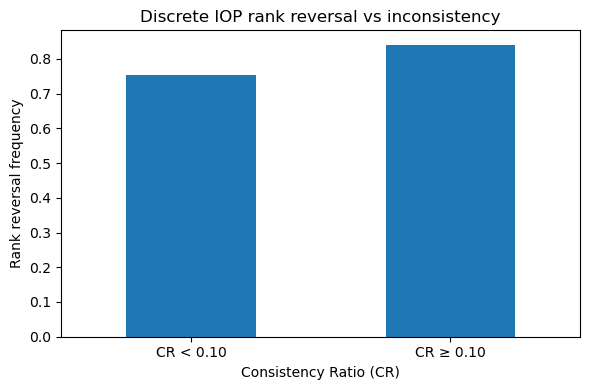


Figure saved to: discrete\discrete_iop_rank_reversal_vs_inconsistency.jpeg


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig

# =========================================================
# 1. Eigenvector priority method
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)

# =========================================================
# 2. Ranking with tolerance (avoid spurious reversals)
# =========================================================

def ranking_with_ties(weights, tol=1e-10):
    """
    Ranking comparison with tolerance:
    two weights are treated as equal if they differ by less than tol.
    Returns rank positions (1 = best).
    """
    n = len(weights)
    ranks = np.zeros(n, dtype=int)

    for i in range(n):
        rank = 1
        for j in range(n):
            if weights[j] > weights[i] + tol:
                rank += 1
        ranks[i] = rank

    return ranks

# =========================================================
# 3. Generate ORDINAL PCM
# =========================================================

def random_ordinal_pcm(n):
    """
    Generate random ordinal reciprocal matrix with entries:
    {1, P, 1/P}
    """

    A = np.ones((n, n), dtype=object)

    for i in range(n):
        for j in range(i + 1, n):

            choice = np.random.choice(["tie", "pref", "notpref"])

            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1

            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"

            else:  # notpref
                A[i, j] = "1/P"
                A[j, i] = "P"

    return A

# =========================================================
# 4. Substitute alpha
# =========================================================

def substitute_alpha(A_ord, alpha):

    n = A_ord.shape[0]
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(n):

            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0

    return A

# =========================================================
# 5. Consistency Ratio (Saaty)
# =========================================================

def consistency_ratio(A):

    n = A.shape[0]

    RI_table = {
        1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
        6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49
    }

    eigenvalues, _ = eig(A)
    lambda_max = np.max(eigenvalues.real)

    CI = (lambda_max - n) / (n - 1)

    RI = RI_table.get(n, None)
    if RI is None:
        raise ValueError("RI not available for n > 10")

    if RI == 0:
        return 0.0

    return CI / RI

# =========================================================
# 6. Discrete simulation with CR (2-group standard)
# =========================================================

def simulate_discrete_reversals_with_cr(n, trials=10000, tol=1e-10):

    records = []
    alpha_values = list(range(2, 10))  # alpha = 2,...,9

    for _ in range(trials):

        # Step 1: ordinal structure
        A_ord = random_ordinal_pcm(n)

        # Step 2: baseline alpha = 2
        A_base = substitute_alpha(A_ord, 2)

        cr = consistency_ratio(A_base)

        w_base = eigenvector_priority(A_base)
        rank_base = ranking_with_ties(w_base, tol)

        reversal = 0

        # Step 3: intensify alpha = 3,...,9
        for alpha in alpha_values[1:]:

            A_new = substitute_alpha(A_ord, alpha)
            w_new = eigenvector_priority(A_new)
            rank_new = ranking_with_ties(w_new, tol)

            if not np.array_equal(rank_base, rank_new):
                reversal = 1
                break

        records.append((cr, reversal))

    return pd.DataFrame(records, columns=["CR", "Reversal"])

# =========================================================
# 7. Create output folder
# =========================================================

output_dir = "discrete"
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# 8. Run experiment
# =========================================================

np.random.seed(42)

n = 7
trials = 10000

print(f"Running DISCRETE CR analysis for n={n}...\n")

df = simulate_discrete_reversals_with_cr(n=n, trials=trials)

# Save raw results
excel_path = os.path.join(output_dir, "discrete_cr_analysis.xlsx")
df.to_excel(excel_path, index=False)

print(f"Raw results saved to: {excel_path}")

# =========================================================
# 9. Group by STANDARD AHP threshold (CR = 0.10)
# =========================================================

bins = [0.0, 0.10, np.inf]
labels = ["CR < 0.10", "CR ≥ 0.10"]

df["CR_group"] = pd.cut(df["CR"], bins=bins, labels=labels)

# Rank reversal frequency by group
summary = df.groupby("CR_group", observed=False)["Reversal"].mean()

# Group sizes
counts = df["CR_group"].value_counts()

print("\nNumber of matrices per CR group:\n")
print(counts)

print("\nRank reversal frequency by CR group:\n")
print(summary)

# Save summary table
summary_df = summary.reset_index()
summary_df.to_excel(
    os.path.join(output_dir, "discrete_cr_summary.xlsx"),
    index=False
)

# =========================================================
# 10. Plot results (journal style)
# =========================================================

ax = summary.plot(kind="bar", figsize=(6, 4))

ax.set_xlabel("Consistency Ratio (CR)")
ax.set_ylabel("Rank reversal frequency")
ax.set_title("Discrete IOP rank reversal vs inconsistency")

plt.xticks(rotation=0)
plt.tight_layout()

figure_path = os.path.join(
    output_dir,
    "discrete_iop_rank_reversal_vs_inconsistency.jpeg"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFigure saved to: {figure_path}")



In [6]:
print(df["CR_group"].value_counts())

CR_group
CR < 0.10    6375
CR ≥ 0.10    3625
Name: count, dtype: int64


Running DISCRETE comparison across 7 methods...

Eigenvector          | n=4 -> 0.0450
Eigenvector          | n=5 -> 0.3763
Eigenvector          | n=6 -> 0.6167
Eigenvector          | n=7 -> 0.7883
Eigenvector          | n=8 -> 0.8943
Geometric mean       | n=4 -> 0.0000
Geometric mean       | n=5 -> 0.0000
Geometric mean       | n=6 -> 0.0000
Geometric mean       | n=7 -> 0.0000
Geometric mean       | n=8 -> 0.0000
Row sum              | n=4 -> 0.0000
Row sum              | n=5 -> 0.0603
Row sum              | n=6 -> 0.1660
Row sum              | n=7 -> 0.3033
Row sum              | n=8 -> 0.4607
Column sum           | n=4 -> 0.1550
Column sum           | n=5 -> 0.4070
Column sum           | n=6 -> 0.6340
Column sum           | n=7 -> 0.8147
Column sum           | n=8 -> 0.9157
Harmonic mean        | n=4 -> 0.0000
Harmonic mean        | n=5 -> 0.0517
Harmonic mean        | n=6 -> 0.1540
Harmonic mean        | n=7 -> 0.2973
Harmonic mean        | n=8 -> 0.4337
Cosine max           | n=4

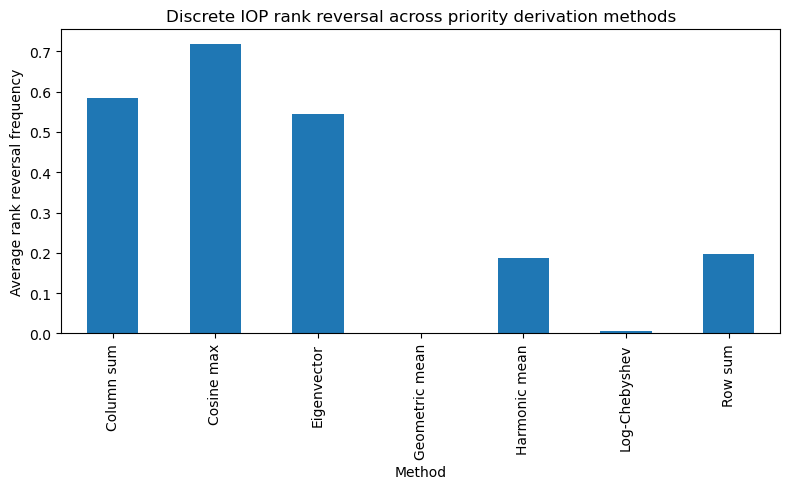


Results saved to: discrete\discrete_comparison_7_methods.xlsx
Figure saved to: discrete\discrete_comparison_7_methods.jpeg

LaTeX table:

\begin{table}
\caption{Average discrete IOP rank reversal frequency across seven priority derivation methods.}
\label{tab:discrete_comparison_7_methods}
\begin{tabular}{lr}
\toprule
 & Frequency \\
Method &  \\
\midrule
Column sum & 0.585300 \\
Cosine max & 0.718600 \\
Eigenvector & 0.544100 \\
Geometric mean & 0.000000 \\
Harmonic mean & 0.187300 \\
Log-Chebyshev & 0.005500 \\
Row sum & 0.198100 \\
\bottomrule
\end{tabular}
\end{table}



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig
from scipy.optimize import linprog

# =========================================================
# 1. Priority derivation methods
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)


def geometric_mean_priority(A):
    gm = np.prod(A, axis=1) ** (1 / A.shape[0])
    return gm / np.sum(gm)


def row_sum_priority(A):
    rs = np.sum(A, axis=1)
    return rs / np.sum(rs)


# ✅ Correct Column Sum Method (CSM)
def column_sum_priority(A):
    """
    Column Sum Method:
    Sum of column-normalised entries.
    """

    col_sums = np.sum(A, axis=0)
    norm_matrix = A / col_sums
    w = np.sum(norm_matrix, axis=1)

    return w / np.sum(w)


def harmonic_mean_priority(A):
    n = A.shape[0]
    hm = n / np.sum(1 / A, axis=1)
    return hm / np.sum(hm)


def cosine_maximization_priority(A):
    n = A.shape[0]
    b = np.zeros_like(A)

    for j in range(n):
        denom = np.sum(A[:, j] ** 2)
        for i in range(n):
            b[i, j] = A[i, j] / denom

    s = np.sum(b, axis=1)
    return s / np.sum(s)


def log_chebyshev_priority(A):
    """
    Log-Chebyshev (Minimax) method via linear programming
    """

    n = A.shape[0]
    logA = np.log(A)

    num_vars = n + 1
    bounds = [(None, None)] * n + [(0, None)]

    A_ub = []
    b_ub = []

    for i in range(n):
        for j in range(n):
            if i != j:

                row1 = np.zeros(num_vars)
                row1[i] = -1
                row1[j] = 1
                row1[-1] = -1
                A_ub.append(row1)
                b_ub.append(-logA[i, j])

                row2 = np.zeros(num_vars)
                row2[i] = 1
                row2[j] = -1
                row2[-1] = -1
                A_ub.append(row2)
                b_ub.append(logA[i, j])

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    c = np.zeros(num_vars)
    c[-1] = 1

    res = linprog(c, A_ub=A_ub, b_ub=b_ub,
                  bounds=bounds, method="highs")

    if not res.success:
        raise RuntimeError("Log-Chebyshev LP did not converge")

    x = res.x[:n]
    w = np.exp(x)

    return w / np.sum(w)

# =========================================================
# 2. Ranking with tolerance
# =========================================================

def ranking_with_ties(weights, tol=1e-10):
    n = len(weights)
    ranks = np.zeros(n, dtype=int)

    for i in range(n):
        rank = 1
        for j in range(n):
            if weights[j] > weights[i] + tol:
                rank += 1
        ranks[i] = rank

    return ranks

# =========================================================
# 3. Generate ORDINAL PCM
# =========================================================

def random_ordinal_pcm(n):

    A = np.ones((n, n), dtype=object)

    for i in range(n):
        for j in range(i + 1, n):

            choice = np.random.choice(["tie", "pref", "notpref"])

            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1

            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"

            else:
                A[i, j] = "1/P"
                A[j, i] = "P"

    return A

# =========================================================
# 4. Substitute alpha
# =========================================================

def substitute_alpha(A_ord, alpha):

    n = A_ord.shape[0]
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(n):

            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0

    return A

# =========================================================
# 5. Discrete rank reversal frequency
# =========================================================

def discrete_rank_reversal_frequency(method, n,
                                     trials=3000, tol=1e-10):

    reversals = 0
    alpha_values = list(range(2, 10))

    for _ in range(trials):

        A_ord = random_ordinal_pcm(n)

        A_base = substitute_alpha(A_ord, 2)
        w_base = method(A_base)
        r_base = ranking_with_ties(w_base, tol)

        reversal = False

        for alpha in alpha_values[1:]:

            A_new = substitute_alpha(A_ord, alpha)
            w_new = method(A_new)
            r_new = ranking_with_ties(w_new, tol)

            if not np.array_equal(r_base, r_new):
                reversal = True
                break

        if reversal:
            reversals += 1

    return reversals / trials

# =========================================================
# 6. Create output folder
# =========================================================

output_dir = "discrete"
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# 7. Run Monte Carlo comparison
# =========================================================

np.random.seed(42)

methods = {
    "Eigenvector": eigenvector_priority,
    "Geometric mean": geometric_mean_priority,
    "Row sum": row_sum_priority,
    "Column sum": column_sum_priority,
    "Harmonic mean": harmonic_mean_priority,
    "Cosine max": cosine_maximization_priority,
    "Log-Chebyshev": log_chebyshev_priority
}

n_values = [4, 5, 6, 7, 8]
trials = 3000
tol = 1e-10

records = []

print("Running DISCRETE comparison across 7 methods...\n")

for name, method in methods.items():
    for n in n_values:

        freq = discrete_rank_reversal_frequency(
            method=method,
            n=n,
            trials=trials,
            tol=tol
        )

        records.append((name, n, freq))
        print(f"{name:20s} | n={n} -> {freq:.4f}")

# =========================================================
# 8. Results table
# =========================================================

df = pd.DataFrame(records,
                  columns=["Method", "n", "Frequency"])

summary = df.groupby("Method")["Frequency"].mean().round(4)

print("\nAverage DISCRETE IOP rank reversal frequency:\n")
print(summary)

excel_path = os.path.join(
    output_dir,
    "discrete_comparison_7_methods.xlsx"
)

df.to_excel(excel_path, index=False)

# =========================================================
# 9. Bar plot
# =========================================================

ax = summary.plot(kind="bar", figsize=(8, 5))

ax.set_ylabel("Average rank reversal frequency")
ax.set_title("Discrete IOP rank reversal across priority derivation methods")

plt.tight_layout()

figure_path = os.path.join(
    output_dir,
    "discrete_comparison_7_methods.jpeg"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nResults saved to: {excel_path}")
print(f"Figure saved to: {figure_path}")

# =========================================================
# 10. LaTeX table
# =========================================================

latex_table = summary.to_frame().to_latex(
    caption="Average discrete IOP rank reversal frequency across seven priority derivation methods.",
    label="tab:discrete_comparison_7_methods"
)

print("\nLaTeX table:\n")
print(latex_table)

In [8]:
#ejemplos

In [9]:
import numpy as np
from numpy.linalg import eig

# =========================================================
# Priority derivation methods
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)

def geometric_mean_priority(A):
    gm = np.prod(A, axis=1) ** (1 / A.shape[0])
    return gm / np.sum(gm)

def arithmetic_mean_priority(A):
    am = np.mean(A, axis=1)
    return am / np.sum(am)

def column_sum_priority(A):
    col_sums = np.sum(A, axis=0)
    norm_matrix = A / col_sums
    w = np.mean(norm_matrix, axis=1)
    return w / np.sum(w)

def sscsm_priority(A):
    col_sums = np.sum(A, axis=0)
    w = np.sum(A / col_sums, axis=1)
    return w / np.sum(w)

def cosine_maximization_priority(A):
    n = A.shape[0]
    b = np.zeros_like(A)
    for j in range(n):
        denom = np.sum(A[:, j] ** 2)
        for i in range(n):
            b[i, j] = A[i, j] / denom
    s = np.sum(b, axis=1)
    return s / np.sum(s)

def express_ahp_priority(A):
    gm = np.prod(A, axis=1) ** (1 / A.shape[0])
    best = np.argmax(gm)
    w = A[:, best]
    return w / np.sum(w)

# =========================================================
# Ranking
# =========================================================

def ranking(weights):
    return np.argsort(-weights)

# =========================================================
# Ordinal PCM generator
# =========================================================

def random_ordinal_pcm(n):
    A = np.ones((n, n), dtype=object)
    for i in range(n):
        for j in range(i + 1, n):
            choice = np.random.choice(["tie", "pref", "notpref"])
            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1
            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"
            else:
                A[i, j] = "1/P"
                A[j, i] = "P"
    return A

# =========================================================
# Substitute alpha
# =========================================================

def substitute_alpha(A_ord, alpha):
    n = A_ord.shape[0]
    A = np.ones((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0
    return A

# =========================================================
# Pretty printing
# =========================================================

def print_matrix(A):
    for row in A:
        print("   ".join(f"{x:6.3f}" for x in row))

def print_weights(w):
    print(", ".join(f"{x:.4f}" for x in w))

# =========================================================
# Find and display explicit rank reversal
# =========================================================

def find_and_print_example(method, method_name, n=5, max_tries=50000):

    alpha_values = list(range(2, 10))

    for attempt in range(max_tries):

        A_ord = random_ordinal_pcm(n)

        A2 = substitute_alpha(A_ord, 2)
        w2 = method(A2)
        r2 = ranking(w2)

        for alpha in alpha_values[1:]:

            Aalpha = substitute_alpha(A_ord, alpha)
            wa = method(Aalpha)
            ra = ranking(wa)

            if not np.array_equal(r2, ra):

                print("="*60)
                print(f"METHOD: {method_name}")
                print(f"Matrix size n = {n}")
                print("-"*60)

                print("\nBaseline α = 2")
                print("Matrix A(2):")
                print_matrix(A2)

                print("\nPriority vector:")
                print_weights(w2)

                print("Ranking:", r2)

                print("\nIntensified α =", alpha)
                print("Matrix A(alpha):")
                print_matrix(Aalpha)

                print("\nPriority vector:")
                print_weights(wa)

                print("Ranking:", ra)

                print("\n>>> IOP RANK REVERSAL DETECTED <<<")
                print("="*60 + "\n")

                return

    print(f"No example found for {method_name}\n")

# =========================================================
# MAIN
# =========================================================

np.random.seed(42)

methods = {
    "Eigenvector": eigenvector_priority,
    "Arithmetic mean": arithmetic_mean_priority,
    "Column sum": column_sum_priority,
    "SSCSM": sscsm_priority,
    "Cosine max": cosine_maximization_priority,
    "Express AHP": express_ahp_priority
}

print("\nSearching explicit rank reversal examples...\n")

for name, method in methods.items():
    find_and_print_example(method, name, n=5)

# =========================================================
# Check geometric mean invariance
# =========================================================

print("\nChecking invariance of geometric mean method...\n")

A_ord = random_ordinal_pcm(5)
A2 = substitute_alpha(A_ord, 2)
A9 = substitute_alpha(A_ord, 9)

w2 = geometric_mean_priority(A2)
w9 = geometric_mean_priority(A9)

print("Ranking at α=2:", ranking(w2))
print("Ranking at α=9:", ranking(w9))
print("\nGeometric mean ranking is invariant.\n")



Searching explicit rank reversal examples...

METHOD: Eigenvector
Matrix size n = 5
------------------------------------------------------------

Baseline α = 2
Matrix A(2):
 1.000    1.000    1.000    2.000    2.000
 1.000    1.000    1.000    1.000    1.000
 1.000    1.000    1.000    0.500    0.500
 0.500    1.000    2.000    1.000    0.500
 0.500    1.000    2.000    2.000    1.000

Priority vector:
0.2636, 0.1888, 0.1514, 0.1713, 0.2249
Ranking: [0 4 1 3 2]

Intensified α = 9
Matrix A(alpha):
 1.000    1.000    1.000    9.000    9.000
 1.000    1.000    1.000    1.000    1.000
 1.000    1.000    1.000    0.111    0.111
 0.111    1.000    9.000    1.000    0.111
 0.111    1.000    9.000    9.000    1.000

Priority vector:
0.4461, 0.1146, 0.0778, 0.1154, 0.2462
Ranking: [0 4 3 1 2]

>>> IOP RANK REVERSAL DETECTED <<<

METHOD: Arithmetic mean
Matrix size n = 5
------------------------------------------------------------

Baseline α = 2
Matrix A(2):
 1.000    2.000    0.500    2.000 

In [10]:
import numpy as np
from numpy.linalg import eig
from scipy.optimize import linprog

# =========================================================
# Priority methods (solo los que faltan)
# =========================================================

def row_sum_priority(A):
    rs = np.sum(A, axis=1)
    return rs / np.sum(rs)

def harmonic_mean_priority(A):
    hm = 1 / np.sum(1 / A, axis=1)
    return hm / np.sum(hm)

def log_chebyshev_priority(A):
    n = A.shape[0]
    logA = np.log(A)

    num_vars = n + 1
    bounds = [(None, None)] * n + [(0, None)]

    A_ub = []
    b_ub = []

    for i in range(n):
        for j in range(n):
            if i != j:
                row1 = np.zeros(num_vars)
                row1[i] = -1
                row1[j] = 1
                row1[-1] = -1
                A_ub.append(row1)
                b_ub.append(-logA[i, j])

                row2 = np.zeros(num_vars)
                row2[i] = 1
                row2[j] = -1
                row2[-1] = -1
                A_ub.append(row2)
                b_ub.append(logA[i, j])

    c = np.zeros(num_vars)
    c[-1] = 1

    res = linprog(c, A_ub=np.array(A_ub),
                  b_ub=np.array(b_ub),
                  bounds=bounds,
                  method="highs")

    x = res.x[:n]
    w = np.exp(x)
    return w / np.sum(w)

# =========================================================
# Ranking
# =========================================================

def ranking(w):
    return np.argsort(-w)

# =========================================================
# Ordinal PCM generator
# =========================================================

def random_ordinal_pcm(n):
    A = np.ones((n, n), dtype=object)
    for i in range(n):
        for j in range(i + 1, n):
            choice = np.random.choice(["tie", "pref", "notpref"])
            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1
            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"
            else:
                A[i, j] = "1/P"
                A[j, i] = "P"
    return A

def substitute_alpha(A_ord, alpha):
    n = A_ord.shape[0]
    A = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0
    return A

# =========================================================
# Pretty print
# =========================================================

def print_matrix(A):
    for row in A:
        print("  ".join(f"{x:6.3f}" for x in row))

def print_weights(w):
    print(", ".join(f"{x:.4f}" for x in w))

# =========================================================
# Find explicit example
# =========================================================

def find_example(method, name, n=5, max_tries=80000):

    for _ in range(max_tries):

        A_ord = random_ordinal_pcm(n)
        A2 = substitute_alpha(A_ord, 2)

        w2 = method(A2)
        r2 = ranking(w2)

        for alpha in range(3, 10):

            Aalpha = substitute_alpha(A_ord, alpha)
            wa = method(Aalpha)
            ra = ranking(wa)

            if not np.array_equal(r2, ra):

                print("="*60)
                print(f"METHOD: {name}")
                print(f"n = {n}")
                print("-"*60)

                print("\nA(2):")
                print_matrix(A2)
                print("\nRanking α=2:", r2)

                print("\nA(alpha), alpha =", alpha)
                print_matrix(Aalpha)
                print("\nRanking α=", alpha, ":", ra)

                print("\n>>> IOP RANK REVERSAL DETECTED <<<")
                print("="*60 + "\n")

                return

    print(f"No example found for {name}")

# =========================================================
# MAIN
# =========================================================

np.random.seed(123)

methods = {
    "Row sum": row_sum_priority,
    "Harmonic mean": harmonic_mean_priority,
    "Log-Chebyshev": log_chebyshev_priority
}

print("\nSearching explicit examples...\n")

for name, method in methods.items():
    find_example(method, name, n=5)



Searching explicit examples...

METHOD: Row sum
n = 5
------------------------------------------------------------

A(2):
 1.000   0.500   2.000   0.500   0.500
 2.000   1.000   1.000   0.500   0.500
 0.500   1.000   1.000   2.000   0.500
 2.000   2.000   0.500   1.000   2.000
 2.000   2.000   2.000   0.500   1.000

Ranking α=2: [3 4 1 2 0]

A(alpha), alpha = 3
 1.000   0.333   3.000   0.333   0.333
 3.000   1.000   1.000   0.333   0.333
 0.333   1.000   1.000   3.000   0.333
 3.000   3.000   0.333   1.000   3.000
 3.000   3.000   3.000   0.333   1.000

Ranking α= 3 : [4 3 1 2 0]

>>> IOP RANK REVERSAL DETECTED <<<

METHOD: Harmonic mean
n = 5
------------------------------------------------------------

A(2):
 1.000   0.500   2.000   1.000   1.000
 2.000   1.000   1.000   1.000   2.000
 0.500   1.000   1.000   0.500   1.000
 1.000   1.000   2.000   1.000   0.500
 1.000   0.500   1.000   2.000   1.000

Ranking α=2: [1 0 3 4 2]

A(alpha), alpha = 3
 1.000   0.333   3.000   1.000   1.00

In [14]:
# =========================================================
# Reviewer Table: Continuous percentages by n and method
# Manual reconstruction from the continuous method-by-n output
# =========================================================

import os
import pandas as pd

OUTPUT_DIR = "continuous_results_methods"
os.makedirs(OUTPUT_DIR, exist_ok=True)

METHOD_ORDER = ["EVM", "RSM", "CSM", "HMM", "CMM"]
N_VALUES = list(range(3, 10))

# Counts over 5000 matrices per n
data = [
    # method, n, matrices, rank_reversal_count, top_change_count
    ("CMM", 3, 5000, 936, 468),
    ("CMM", 4, 5000, 2226, 946),
    ("CMM", 5, 5000, 3407, 1374),
    ("CMM", 6, 5000, 4102, 1481),
    ("CMM", 7, 5000, 4483, 1464),
    ("CMM", 8, 5000, 4734, 1561),
    ("CMM", 9, 5000, 4873, 1563),

    ("CSM", 3, 5000, 146, 69),
    ("CSM", 4, 5000, 1290, 341),
    ("CSM", 5, 5000, 2346, 519),
    ("CSM", 6, 5000, 3330, 699),
    ("CSM", 7, 5000, 3977, 799),
    ("CSM", 8, 5000, 4458, 1006),
    ("CSM", 9, 5000, 4734, 1079),

    ("EVM", 3, 5000, 0, 0),
    ("EVM", 4, 5000, 968, 383),
    ("EVM", 5, 5000, 2263, 709),
    ("EVM", 6, 5000, 3339, 838),
    ("EVM", 7, 5000, 3994, 956),
    ("EVM", 8, 5000, 4450, 1045),
    ("EVM", 9, 5000, 4731, 1072),

    ("HMM", 3, 5000, 477, 29),
    ("HMM", 4, 5000, 1464, 221),
    ("HMM", 5, 5000, 2557, 452),
    ("HMM", 6, 5000, 3388, 666),
    ("HMM", 7, 5000, 4039, 825),
    ("HMM", 8, 5000, 4447, 908),
    ("HMM", 9, 5000, 4685, 934),

    ("RSM", 3, 5000, 449, 422),
    ("RSM", 4, 5000, 1421, 676),
    ("RSM", 5, 5000, 2499, 852),
    ("RSM", 6, 5000, 3436, 891),
    ("RSM", 7, 5000, 3998, 931),
    ("RSM", 8, 5000, 4422, 990),
    ("RSM", 9, 5000, 4686, 1024),
]

df = pd.DataFrame(
    data,
    columns=[
        "method",
        "n",
        "matrices",
        "rank_reversal_count",
        "top_change_count",
    ],
)

df["rank_reversal_percent"] = 100 * df["rank_reversal_count"] / df["matrices"]
df["top_change_percent"] = 100 * df["top_change_count"] / df["matrices"]

rank_table = (
    df.pivot(index="n", columns="method", values="rank_reversal_percent")
    .reindex(index=N_VALUES, columns=METHOD_ORDER)
    .round(1)
)

top_table = (
    df.pivot(index="n", columns="method", values="top_change_percent")
    .reindex(index=N_VALUES, columns=METHOD_ORDER)
    .round(1)
)

rank_table_out = rank_table.reset_index()
top_table_out = top_table.reset_index()

# Save Excel
excel_path = os.path.join(
    OUTPUT_DIR,
    "table_continuous_percentages_by_n_and_method.xlsx"
)

with pd.ExcelWriter(excel_path) as writer:
    rank_table_out.to_excel(writer, sheet_name="rank_reversal", index=False)
    top_table_out.to_excel(writer, sheet_name="top_change", index=False)

# Build LaTeX in your article style
def fmt(x):
    if pd.isna(x):
        return "--"
    return f"${x:.1f}\\%$"

latex_lines = []

latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begingroup")
latex_lines.append(r"\color{blue}")
latex_lines.append(r"\resizebox{\textwidth}{!}{")
latex_lines.append(r"\begin{tabular}{|r|rrrrr|rrrrr|}")
latex_lines.append(r"\hline")
latex_lines.append(r"\multicolumn{1}{|c|}{} &")
latex_lines.append(r"\multicolumn{5}{c|}{IOP rank reversal} &")
latex_lines.append(r"\multicolumn{5}{c|}{Top-ranked alternative change} \\")
latex_lines.append(r"\hline")
latex_lines.append(r"$n$ &")
latex_lines.append(r"EVM & RSM & CSM & HMM & CMM &")
latex_lines.append(r"EVM & RSM & CSM & HMM & CMM \\")
latex_lines.append(r"\hline")

for n in N_VALUES:
    rr = rank_table.loc[n]
    tc = top_table.loc[n]

    line = (
        f"{n} & "
        f"{fmt(rr['EVM'])} & {fmt(rr['RSM'])} & {fmt(rr['CSM'])} & {fmt(rr['HMM'])} & {fmt(rr['CMM'])} & "
        f"{fmt(tc['EVM'])} & {fmt(tc['RSM'])} & {fmt(tc['CSM'])} & {fmt(tc['HMM'])} & {fmt(tc['CMM'])} \\\\"
    )
    latex_lines.append(line)

latex_lines.append(r"\hline")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"}")
latex_lines.append(
    r"\caption{Continuous intensity-of-preference rank-reversal and top-ranked alternative change percentages by matrix order and priority derivation method. Percentages are computed over the same fixed set of 5000 continuous reciprocal matrices for each matrix order $n$, with heterogeneous strict-preference intensities $U_{ij}\sim\mathrm{Unif}[1.2,9]$. Each baseline matrix $A$ is compared with its uniformly intensified version $A^{(2)}=[a_{ij}^{2}]$.}"
)
latex_lines.append(r"\label{tab:continuous_percentages_by_n_method}")
latex_lines.append(r"\endgroup")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)

latex_path = os.path.join(
    OUTPUT_DIR,
    "table_continuous_percentages_by_n_and_method.tex"
)

with open(latex_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print("\nPanel A: IOP rank reversal percentages")
display(rank_table_out)

print("\nPanel B: Top-ranked alternative change percentages")
display(top_table_out)

print("\nFiles saved:")
print(excel_path)
print(latex_path)

print("\nLaTeX table:")
print(latex_table)


Panel A: IOP rank reversal percentages


method,n,EVM,RSM,CSM,HMM,CMM
0,3,0.0,9.0,2.9,9.5,18.7
1,4,19.4,28.4,25.8,29.3,44.5
2,5,45.3,50.0,46.9,51.1,68.1
3,6,66.8,68.7,66.6,67.8,82.0
4,7,79.9,80.0,79.5,80.8,89.7
5,8,89.0,88.4,89.2,88.9,94.7
6,9,94.6,93.7,94.7,93.7,97.5



Panel B: Top-ranked alternative change percentages


method,n,EVM,RSM,CSM,HMM,CMM
0,3,0.0,8.4,1.4,0.6,9.4
1,4,7.7,13.5,6.8,4.4,18.9
2,5,14.2,17.0,10.4,9.0,27.5
3,6,16.8,17.8,14.0,13.3,29.6
4,7,19.1,18.6,16.0,16.5,29.3
5,8,20.9,19.8,20.1,18.2,31.2
6,9,21.4,20.5,21.6,18.7,31.3



Files saved:
continuous_results_methods\table_continuous_percentages_by_n_and_method.xlsx
continuous_results_methods\table_continuous_percentages_by_n_and_method.tex

LaTeX table:
\begin{table}[H]
\centering
\begingroup
\color{blue}
\resizebox{\textwidth}{!}{
\begin{tabular}{|r|rrrrr|rrrrr|}
\hline
\multicolumn{1}{|c|}{} &
\multicolumn{5}{c|}{IOP rank reversal} &
\multicolumn{5}{c|}{Top-ranked alternative change} \\
\hline
$n$ &
EVM & RSM & CSM & HMM & CMM &
EVM & RSM & CSM & HMM & CMM \\
\hline
3 & $0.0\%$ & $9.0\%$ & $2.9\%$ & $9.5\%$ & $18.7\%$ & $0.0\%$ & $8.4\%$ & $1.4\%$ & $0.6\%$ & $9.4\%$ \\
4 & $19.4\%$ & $28.4\%$ & $25.8\%$ & $29.3\%$ & $44.5\%$ & $7.7\%$ & $13.5\%$ & $6.8\%$ & $4.4\%$ & $18.9\%$ \\
5 & $45.3\%$ & $50.0\%$ & $46.9\%$ & $51.1\%$ & $68.1\%$ & $14.2\%$ & $17.0\%$ & $10.4\%$ & $9.0\%$ & $27.5\%$ \\
6 & $66.8\%$ & $68.7\%$ & $66.6\%$ & $67.8\%$ & $82.0\%$ & $16.8\%$ & $17.8\%$ & $14.0\%$ & $13.3\%$ & $29.6\%$ \\
7 & $79.9\%$ & $80.0\%$ & $79.5\%$ & $80.8\%$ & $89

In [16]:
import os
import json
import numpy as np

# =========================================================
# Regenerate the old continuous matrix bank used for Figure 4/Table 5
# =========================================================

SEED = 42
TRIALS_PER_N = 5000
N_VALUES = list(range(3, 10))

P_TIE = 1.0 / 3.0
LOW = 1.2
HIGH = 9.0

OUTPUT_DIR = "continuous_shared_matrices"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MATRIX_BANK_PATH = os.path.join(
    OUTPUT_DIR,
    "continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0.npz"
)

METADATA_PATH = os.path.join(
    OUTPUT_DIR,
    "continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0_metadata.json"
)

def generate_one_continuous_pcm(n, rng):
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(i + 1, n):

            u = rng.random()

            if u < P_TIE:
                A[i, j] = 1.0
                A[j, i] = 1.0
            else:
                intensity = rng.uniform(LOW, HIGH)

                if rng.random() < 0.5:
                    A[i, j] = intensity
                    A[j, i] = 1.0 / intensity
                else:
                    A[i, j] = 1.0 / intensity
                    A[j, i] = intensity

    return A

rng = np.random.default_rng(SEED)

matrix_bank = {}

for n in N_VALUES:
    matrices_n = np.zeros((TRIALS_PER_N, n, n), dtype=float)

    for matrix_id in range(TRIALS_PER_N):
        matrices_n[matrix_id] = generate_one_continuous_pcm(n, rng)

    matrix_bank[f"n_{n}"] = matrices_n
    print(f"Generated {TRIALS_PER_N} continuous matrices for n={n}")

np.savez_compressed(MATRIX_BANK_PATH, **matrix_bank)

metadata = {
    "seed": SEED,
    "trials_per_n": TRIALS_PER_N,
    "n_values": N_VALUES,
    "p_tie": P_TIE,
    "strict_intensity_distribution": f"Uniform[{LOW}, {HIGH}]",
    "intensification": "A^(2) = [a_ij^2]",
    "description": (
        "Continuous reciprocal matrices generated with the old naming convention "
        "used for Figure 4 and Table 5."
    )
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("\nMatrix bank saved to:")
print(MATRIX_BANK_PATH)

print("\nMetadata saved to:")
print(METADATA_PATH)

Generated 5000 continuous matrices for n=3
Generated 5000 continuous matrices for n=4
Generated 5000 continuous matrices for n=5
Generated 5000 continuous matrices for n=6
Generated 5000 continuous matrices for n=7
Generated 5000 continuous matrices for n=8
Generated 5000 continuous matrices for n=9

Matrix bank saved to:
continuous_shared_matrices\continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0.npz

Metadata saved to:
continuous_shared_matrices\continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0_metadata.json


In [22]:
# =========================================================
# CELL 1 — Regenerate the correct continuous matrix bank
# This matches Figure 4 / Table 5
# =========================================================

import os
import json
import numpy as np

SEED = 42
TRIALS_PER_N = 5000
N_VALUES = list(range(3, 10))

LOW = 1.2
HIGH = 9.0

INPUT_DIR = "continuous_shared_matrices"
os.makedirs(INPUT_DIR, exist_ok=True)

MATRIX_BANK_PATH = os.path.join(
    INPUT_DIR,
    "continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0.npz"
)

METADATA_PATH = os.path.join(
    INPUT_DIR,
    "continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0_metadata.json"
)

def generate_one_continuous_pcm(n, rng):
    """
    Continuous reciprocal matrix with three equiprobable ordinal outcomes:
        0 = tie,
        1 = i preferred to j,
        2 = j preferred to i.

    In strict comparisons, the intensity is drawn from Uniform[1.2, 9].
    """
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(i + 1, n):

            outcome = rng.choice(3)

            if outcome == 0:
                A[i, j] = 1.0
                A[j, i] = 1.0

            else:
                intensity = rng.uniform(LOW, HIGH)

                if outcome == 1:
                    A[i, j] = intensity
                    A[j, i] = 1.0 / intensity

                else:
                    A[i, j] = 1.0 / intensity
                    A[j, i] = intensity

    return A

rng = np.random.default_rng(SEED)

matrix_bank = {}

for n in N_VALUES:
    mats = np.zeros((TRIALS_PER_N, n, n), dtype=float)

    for matrix_id in range(TRIALS_PER_N):
        mats[matrix_id] = generate_one_continuous_pcm(n, rng)

    matrix_bank[f"n_{n}"] = mats
    print(f"Generated {TRIALS_PER_N} matrices for n={n}")

np.savez_compressed(MATRIX_BANK_PATH, **matrix_bank)

metadata = {
    "seed": SEED,
    "trials_per_n": TRIALS_PER_N,
    "n_values": N_VALUES,
    "ordinal_outcomes": "tie, i preferred to j, j preferred to i",
    "outcome_probabilities": "1/3, 1/3, 1/3",
    "strict_intensity_distribution": f"Uniform[{LOW}, {HIGH}]",
    "intensification": "A^(2) = [a_ij^2]",
    "description": "Continuous matrix bank matching Figure 4 / Table 5."
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("\nSaved matrix bank to:")
print(MATRIX_BANK_PATH)

print("\nSaved metadata to:")
print(METADATA_PATH)

Generated 5000 matrices for n=3
Generated 5000 matrices for n=4
Generated 5000 matrices for n=5
Generated 5000 matrices for n=6
Generated 5000 matrices for n=7
Generated 5000 matrices for n=8
Generated 5000 matrices for n=9

Saved matrix bank to:
continuous_shared_matrices\continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0.npz

Saved metadata to:
continuous_shared_matrices\continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0_metadata.json


Using continuous matrix bank:
continuous_shared_matrices\continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0.npz
Running n=3; matrices=5000
Running n=4; matrices=5000
Running n=5; matrices=5000
Running n=6; matrices=5000
Running n=7; matrices=5000
Running n=8; matrices=5000
Running n=9; matrices=5000

EVM check (should be close to Figure 4 / Table 5):


,n,mean_cr,median_cr,rank_reversal_percent,top_change_percent
14,3,0.5490,0.2661,0.00,0.00
15,4,0.5901,0.4668,14.08,5.00
16,5,0.6091,0.5504,37.90,11.88
17,6,0.6085,0.5813,61.30,16.56
18,7,0.6193,0.6087,78.72,20.24
19,8,0.6069,0.6015,89.26,23.02
20,9,0.6217,0.6210,94.76,24.52


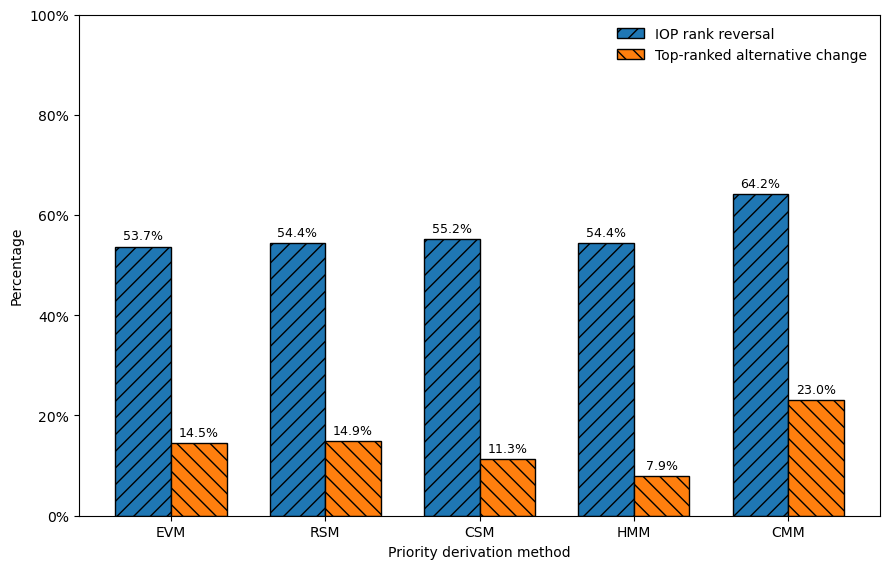


Panel A: IOP rank reversal percentages


method,n,EVM,RSM,CSM,HMM,CMM
0,3,0.0,4.9,2.9,5.3,6.7
1,4,14.1,20.9,21.2,20.5,30.5
2,5,37.9,41.8,42.7,40.7,56.0
3,6,61.3,60.0,61.5,60.1,75.0
4,7,78.7,75.1,77.3,76.3,87.9
5,8,89.3,85.7,87.3,85.4,95.1
6,9,94.8,92.7,93.3,92.5,98.0



Panel B: Top-ranked alternative change percentages


method,n,EVM,RSM,CSM,HMM,CMM
0,3,0.0,4.1,1.3,0.7,3.5
1,4,5.0,12.3,5.6,2.7,11.9
2,5,11.9,16.2,9.3,5.6,19.6
3,6,16.6,17.7,12.8,7.6,26.3
4,7,20.2,17.2,14.9,10.8,30.2
5,8,23.0,18.4,16.7,12.6,33.2
6,9,24.5,18.5,18.5,15.1,36.0



Figure 5 averages


,method,rank_reversal_percent,top_change_percent
0,EVM,53.7,14.5
1,RSM,54.4,14.9
2,CSM,55.2,11.3
3,HMM,54.4,7.9
4,CMM,64.2,23.0



Files saved:
continuous_results_methods\table_continuous_percentages_by_n_and_method_fixed.xlsx
continuous_results_methods\figure_5_continuous_methods_fixed.png
continuous_results_methods\figure_5_continuous_methods_fixed.pdf
continuous_results_methods\table_continuous_percentages_by_n_and_method_fixed.tex

LaTeX table:
\begin{table}[H]
\centering
\begingroup
\color{blue}
\resizebox{\textwidth}{!}{
\begin{tabular}{|r|rrrrr|rrrrr|}
\hline
\multicolumn{1}{|c|}{} &
\multicolumn{5}{c|}{IOP rank reversal} &
\multicolumn{5}{c|}{Top-ranked alternative change} \\
\hline
$n$ &
EVM & RSM & CSM & HMM & CMM &
EVM & RSM & CSM & HMM & CMM \\
\hline
3 & $0.0\%$ & $4.9\%$ & $2.9\%$ & $5.3\%$ & $6.7\%$ & $0.0\%$ & $4.1\%$ & $1.3\%$ & $0.7\%$ & $3.5\%$ \\
4 & $14.1\%$ & $20.9\%$ & $21.2\%$ & $20.5\%$ & $30.5\%$ & $5.0\%$ & $12.3\%$ & $5.6\%$ & $2.7\%$ & $11.9\%$ \\
5 & $37.9\%$ & $41.8\%$ & $42.7\%$ & $40.7\%$ & $56.0\%$ & $11.9\%$ & $16.2\%$ & $9.3\%$ & $5.6\%$ & $19.6\%$ \\
6 & $61.3\%$ & $60.0\%$ & 

In [23]:
# =========================================================
# CELL 2 — Recompute Figure 5 and Table 6
# so that they are consistent with Figure 4 / Table 5
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import eig
from scipy.optimize import minimize
from matplotlib.ticker import PercentFormatter

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

N_VALUES = list(range(3, 10))
METHOD_ORDER = ["EVM", "RSM", "CSM", "HMM", "CMM"]

INPUT_DIR = "continuous_shared_matrices"
OUTPUT_DIR = "continuous_results_methods"

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

MATRIX_BANK_PATH = os.path.join(
    INPUT_DIR,
    "continuous_matrix_bank_seed_42_trials_5000_amin_1.2_amax_9.0.npz"
)

INTENSIFICATION_POWER = 2.0
RANK_TOL = 1e-10
LOG_WEIGHT_BOUND = 8.0
OPT_MAXITER = 300

RI_VALUES = {
    1: 0.00,
    2: 0.00,
    3: 0.58,
    4: 0.90,
    5: 1.12,
    6: 1.24,
    7: 1.32,
    8: 1.41,
    9: 1.45,
    10: 1.49,
}

print("=" * 80)
print("Using continuous matrix bank:")
print(MATRIX_BANK_PATH)
print("=" * 80)

if not os.path.exists(MATRIX_BANK_PATH):
    raise FileNotFoundError(
        f"Matrix bank not found:\n{MATRIX_BANK_PATH}\n"
        "Run CELL 1 first."
    )

# ---------------------------------------------------------
# Utilities
# ---------------------------------------------------------

def normalize_positive(w):
    w = np.asarray(w, dtype=float)
    if np.any(~np.isfinite(w)):
        raise ValueError("Priority vector contains non-finite values.")
    if np.any(w < 0):
        raise ValueError("Priority vector contains negative values.")
    total = np.sum(w)
    if total <= 0:
        raise ValueError("Priority vector has non-positive sum.")
    return w / total

def principal_eigenpair(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    lambda_max = eigenvalues[idx].real
    w = eigenvectors[:, idx].real
    if np.sum(w) < 0:
        w = -w
    if np.any(w <= 0):
        w = np.abs(w)
    w = normalize_positive(w)
    return lambda_max, w

def consistency_ratio(A):
    n = A.shape[0]
    if n <= 2:
        return 0.0
    lambda_max, _ = principal_eigenpair(A)
    ci = (lambda_max - n) / (n - 1)
    ci = max(0.0, ci)
    ri = RI_VALUES[n]
    if ri == 0:
        return 0.0
    return ci / ri

# ---------------------------------------------------------
# Priority derivation methods
# ---------------------------------------------------------

def eigenvector_priority(A):
    _, w = principal_eigenpair(A)
    return w

def row_sum_priority(A):
    rs = np.sum(A, axis=1)
    return normalize_positive(rs)

def column_sum_priority(A):
    col_sums = np.sum(A, axis=0)
    norm_matrix = A / col_sums
    w = np.sum(norm_matrix, axis=1)
    return normalize_positive(w)

def harmonic_mean_priority(A):
    n = A.shape[0]
    hm = n / np.sum(1.0 / A, axis=1)
    return normalize_positive(hm)

def geometric_mean_start(A):
    gm = np.prod(A, axis=1) ** (1.0 / A.shape[0])
    gm = normalize_positive(gm)
    return np.log(gm)

def fixed_scale_log_vector(z):
    z = np.asarray(z, dtype=float)
    z = np.clip(z, -LOG_WEIGHT_BOUND, LOG_WEIGHT_BOUND)
    return np.concatenate([z, np.array([0.0])])

def ratio_matrix_from_log_vector(x):
    x = np.asarray(x, dtype=float)
    d = x[:, None] - x[None, :]
    d = np.clip(d, -2 * LOG_WEIGHT_BOUND, 2 * LOG_WEIGHT_BOUND)
    return np.exp(d)

def cosine_maximization_priority(A):
    n = A.shape[0]
    norm_A = np.linalg.norm(A)

    if norm_A <= 0:
        raise ValueError("Invalid matrix norm.")

    log_start = geometric_mean_start(A)
    z0 = log_start[:-1] - log_start[-1]
    z0 = np.clip(z0, -LOG_WEIGHT_BOUND, LOG_WEIGHT_BOUND)

    bounds = [(-LOG_WEIGHT_BOUND, LOG_WEIGHT_BOUND)] * (n - 1)

    def objective(z):
        x = fixed_scale_log_vector(z)
        R = ratio_matrix_from_log_vector(x)

        numerator = np.sum(A * R)
        norm_R = np.linalg.norm(R)

        if norm_R <= 0 or not np.isfinite(norm_R):
            return 1e100

        cosine = numerator / (norm_A * norm_R)

        if not np.isfinite(cosine):
            return 1e100

        return -cosine

    res = minimize(
        objective,
        z0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": OPT_MAXITER, "ftol": 1e-10},
    )

    if not res.success:
        raise RuntimeError(f"CMM optimisation did not converge: {res.message}")

    x = fixed_scale_log_vector(res.x)
    w = np.exp(x - np.max(x))
    return normalize_positive(w)

PRIORITY_METHODS = {
    "EVM": eigenvector_priority,
    "RSM": row_sum_priority,
    "CSM": column_sum_priority,
    "HMM": harmonic_mean_priority,
    "CMM": cosine_maximization_priority,
}

# ---------------------------------------------------------
# Ranking comparison
# ---------------------------------------------------------

def pairwise_order_matrix(weights, tol=RANK_TOL):
    w = np.asarray(weights, dtype=float)
    n = len(w)

    scale = max(1.0, np.max(np.abs(w)))
    eps = tol * scale

    order = np.zeros((n, n), dtype=np.int8)

    for i in range(n):
        for j in range(n):
            diff = w[i] - w[j]
            if diff > eps:
                order[i, j] = 1
            elif diff < -eps:
                order[i, j] = -1
            else:
                order[i, j] = 0

    return order

def rank_reversal_occurred(w_base, w_new, tol=RANK_TOL):
    return not np.array_equal(
        pairwise_order_matrix(w_base, tol),
        pairwise_order_matrix(w_new, tol),
    )

def top_set(weights, tol=RANK_TOL):
    w = np.asarray(weights, dtype=float)
    scale = max(1.0, np.max(np.abs(w)))
    eps = tol * scale
    max_w = np.max(w)
    return set(np.where(max_w - w <= eps)[0])

def top_rank_change_occurred(w_base, w_new, tol=RANK_TOL):
    base_top = top_set(w_base, tol)
    new_top = top_set(w_new, tol)
    return len(base_top.intersection(new_top)) == 0

# ---------------------------------------------------------
# Load bank
# ---------------------------------------------------------

def load_matrix_bank():
    data = np.load(MATRIX_BANK_PATH)
    matrix_bank = {}
    for key in data.files:
        n = int(key.split("_")[1])
        matrix_bank[n] = data[key]
    return matrix_bank

# ---------------------------------------------------------
# Run experiment
# ---------------------------------------------------------

def run_experiment(matrix_bank):
    rows = []

    for n in N_VALUES:
        mats = matrix_bank[n]
        print(f"Running n={n}; matrices={mats.shape[0]}")

        for matrix_id, A in enumerate(mats):
            A2 = A ** INTENSIFICATION_POWER
            cr = consistency_ratio(A)

            for method_name, method_func in PRIORITY_METHODS.items():
                try:
                    w_base = method_func(A)
                    w_new = method_func(A2)

                    rows.append({
                        "method": method_name,
                        "n": n,
                        "matrix_id": matrix_id,
                        "cr_base": cr,
                        "success": True,
                        "rank_reversal": rank_reversal_occurred(w_base, w_new),
                        "top_change": top_rank_change_occurred(w_base, w_new),
                    })

                except Exception:
                    rows.append({
                        "method": method_name,
                        "n": n,
                        "matrix_id": matrix_id,
                        "cr_base": cr,
                        "success": False,
                        "rank_reversal": np.nan,
                        "top_change": np.nan,
                    })

    return pd.DataFrame(rows)

# ---------------------------------------------------------
# Summaries
# ---------------------------------------------------------

def build_summaries(results_df):
    successful = results_df[results_df["success"]].copy()

    summary_by_method_n = (
        successful
        .groupby(["method", "n"])
        .agg(
            matrices=("matrix_id", "count"),
            rank_reversal_count=("rank_reversal", "sum"),
            top_change_count=("top_change", "sum"),
            mean_cr=("cr_base", "mean"),
            median_cr=("cr_base", "median"),
        )
        .reset_index()
    )

    summary_by_method_n["rank_reversal_frequency"] = (
        summary_by_method_n["rank_reversal_count"] /
        summary_by_method_n["matrices"]
    )

    summary_by_method_n["top_change_frequency"] = (
        summary_by_method_n["top_change_count"] /
        summary_by_method_n["matrices"]
    )

    average_by_method = (
        summary_by_method_n
        .groupby("method")
        .agg(
            average_rank_reversal_frequency=("rank_reversal_frequency", "mean"),
            average_top_change_frequency=("top_change_frequency", "mean"),
        )
        .reset_index()
    )

    return summary_by_method_n, average_by_method

# ---------------------------------------------------------
# Execute
# ---------------------------------------------------------

matrix_bank = load_matrix_bank()
results_df = run_experiment(matrix_bank)
summary_by_method_n, average_by_method = build_summaries(results_df)

# ---------------------------------------------------------
# EVM check: should match Figure 4 / Table 5
# ---------------------------------------------------------

evm_check = summary_by_method_n[
    summary_by_method_n["method"].eq("EVM")
].copy()

evm_check["rank_reversal_percent"] = 100 * evm_check["rank_reversal_frequency"]
evm_check["top_change_percent"] = 100 * evm_check["top_change_frequency"]

evm_check = evm_check[
    ["n", "mean_cr", "median_cr", "rank_reversal_percent", "top_change_percent"]
].round(4)

print("\nEVM check (should be close to Figure 4 / Table 5):")
display(evm_check)

# ---------------------------------------------------------
# Build Table 6
# ---------------------------------------------------------

df = summary_by_method_n.copy()
df["rank_reversal_percent"] = 100 * df["rank_reversal_frequency"]
df["top_change_percent"] = 100 * df["top_change_frequency"]

rank_table = (
    df.pivot(index="n", columns="method", values="rank_reversal_percent")
    .reindex(index=N_VALUES, columns=METHOD_ORDER)
    .round(1)
)

top_table = (
    df.pivot(index="n", columns="method", values="top_change_percent")
    .reindex(index=N_VALUES, columns=METHOD_ORDER)
    .round(1)
)

rank_table_out = rank_table.reset_index()
top_table_out = top_table.reset_index()

# ---------------------------------------------------------
# Build Figure 5 averages
# ---------------------------------------------------------

average_table = pd.DataFrame({
    "method": METHOD_ORDER,
    "rank_reversal_percent": [rank_table[m].mean() for m in METHOD_ORDER],
    "top_change_percent": [top_table[m].mean() for m in METHOD_ORDER],
}).round(1)

# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

excel_path = os.path.join(
    OUTPUT_DIR,
    "table_continuous_percentages_by_n_and_method_fixed.xlsx"
)

with pd.ExcelWriter(excel_path) as writer:
    results_df.to_excel(writer, sheet_name="all_results", index=False)
    summary_by_method_n.to_excel(writer, sheet_name="summary_method_n", index=False)
    rank_table_out.to_excel(writer, sheet_name="rank_reversal", index=False)
    top_table_out.to_excel(writer, sheet_name="top_change", index=False)
    average_table.to_excel(writer, sheet_name="figure5_averages", index=False)

# ---------------------------------------------------------
# Figure 5 with labels
# ---------------------------------------------------------

x = np.arange(len(METHOD_ORDER))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5.8))

bars_rr = ax.bar(
    x - width / 2,
    average_table["rank_reversal_percent"],
    width,
    label="IOP rank reversal",
    edgecolor="black",
    hatch="//",
)

bars_top = ax.bar(
    x + width / 2,
    average_table["top_change_percent"],
    width,
    label="Top-ranked alternative change",
    edgecolor="black",
    hatch="\\\\",
)

for bars in [bars_rr, bars_top]:
    labels = [f"{bar.get_height():.1f}%" for bar in bars]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=9)

ax.set_xlabel("Priority derivation method")
ax.set_ylabel("Percentage")
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.legend(frameon=False)

plt.tight_layout()

figure_png_path = os.path.join(
    OUTPUT_DIR,
    "figure_5_continuous_methods_fixed.png"
)

figure_pdf_path = os.path.join(
    OUTPUT_DIR,
    "figure_5_continuous_methods_fixed.pdf"
)

fig.savefig(figure_png_path, dpi=300, bbox_inches="tight")
fig.savefig(figure_pdf_path, bbox_inches="tight")

plt.show()

# ---------------------------------------------------------
# LaTeX table
# ---------------------------------------------------------

def fmt(x):
    if pd.isna(x):
        return "--"
    return f"${x:.1f}\\%$"

latex_lines = []
latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begingroup")
latex_lines.append(r"\color{blue}")
latex_lines.append(r"\resizebox{\textwidth}{!}{")
latex_lines.append(r"\begin{tabular}{|r|rrrrr|rrrrr|}")
latex_lines.append(r"\hline")
latex_lines.append(r"\multicolumn{1}{|c|}{} &")
latex_lines.append(r"\multicolumn{5}{c|}{IOP rank reversal} &")
latex_lines.append(r"\multicolumn{5}{c|}{Top-ranked alternative change} \\")
latex_lines.append(r"\hline")
latex_lines.append(r"$n$ &")
latex_lines.append(r"EVM & RSM & CSM & HMM & CMM &")
latex_lines.append(r"EVM & RSM & CSM & HMM & CMM \\")
latex_lines.append(r"\hline")

for n in N_VALUES:
    rr = rank_table.loc[n]
    tc = top_table.loc[n]

    line = (
        f"{n} & "
        f"{fmt(rr['EVM'])} & {fmt(rr['RSM'])} & {fmt(rr['CSM'])} & {fmt(rr['HMM'])} & {fmt(rr['CMM'])} & "
        f"{fmt(tc['EVM'])} & {fmt(tc['RSM'])} & {fmt(tc['CSM'])} & {fmt(tc['HMM'])} & {fmt(tc['CMM'])} \\\\"
    )
    latex_lines.append(line)

latex_lines.append(r"\hline")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"}")
latex_lines.append(
    r"\caption{Continuous intensity-of-preference rank-reversal and top-ranked alternative change percentages by matrix order and priority derivation method. Percentages are computed over the same fixed set of 5000 continuous reciprocal matrices for each matrix order $n$, with heterogeneous strict-preference intensities $U_{ij}\sim\mathrm{Unif}[1.2,9]$. A matrix is counted as exhibiting IOP rank reversal, respectively top-ranked alternative change, if the event occurs when comparing the baseline matrix $A$ with its uniformly intensified version $A^{(2)}=[a_{ij}^{2}]$.}"
)
latex_lines.append(r"\label{tab:continuous_percentages_by_n_method}")
latex_lines.append(r"\endgroup")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)

latex_path = os.path.join(
    OUTPUT_DIR,
    "table_continuous_percentages_by_n_and_method_fixed.tex"
)

with open(latex_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print("\nPanel A: IOP rank reversal percentages")
display(rank_table_out)

print("\nPanel B: Top-ranked alternative change percentages")
display(top_table_out)

print("\nFigure 5 averages")
display(average_table)

print("\nFiles saved:")
print(excel_path)
print(figure_png_path)
print(figure_pdf_path)
print(latex_path)

print("\nLaTeX table:")
print(latex_table)